In [ ]:
# ============================================
# HCP ENGAGEMENT HISTORY DATASET
# SECTION 1: BASIC DATASET UNDERSTANDING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Engagement_history_improved.csv")

# ------------------------------------------------
# 1. Dataset Shape
# ------------------------------------------------

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


# ------------------------------------------------
# 2. First 5 Records
# ------------------------------------------------

print("\nFirst 5 Records:")
display(df.head())


# ------------------------------------------------
# 3. Last 5 Records
# ------------------------------------------------

print("\nLast 5 Records:")
display(df.tail())


# ------------------------------------------------
# 4. Column Names
# ------------------------------------------------

print("\nColumn Names:")
print(df.columns.tolist())


# ------------------------------------------------
# 5. Data Types
# ------------------------------------------------

print("\nData Types:")
print(df.dtypes)


# ------------------------------------------------
# 6. Dataset Information
# ------------------------------------------------

print("\nDataset Information:")
df.info()


# ------------------------------------------------
# 7. Unique Values in Each Column
# ------------------------------------------------

print("\nNumber of Unique Values:")
print(df.nunique())

Dataset Shape:
(11039, 4)

Number of Rows: 11039
Number of Columns: 4

First 5 Records:


,hcp_id,engagement_date,channel,engagement_successful
0,1,2025-01-16 17:00:00,email,1
1,1,2025-02-21 16:00:00,email,1
2,1,2025-02-25 16:00:00,email,0
3,1,2025-03-13 14:00:00,email,0
4,1,2025-03-25 11:00:00,email,0



Last 5 Records:


,hcp_id,engagement_date,channel,engagement_successful
11034,500,2025-09-03 14:00:00,rep_visit,1
11035,500,2025-09-19 10:00:00,phone_call,1
11036,500,2025-09-26 15:00:00,email,0
11037,500,2025-10-06 11:00:00,digital_ad,0
11038,500,2025-10-13 09:00:00,email,0



Column Names:
['hcp_id', 'engagement_date', 'channel', 'engagement_successful']

Data Types:
hcp_id                    int64
engagement_date          object
channel                  object
engagement_successful     int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11039 entries, 0 to 11038
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   hcp_id                 11039 non-null  int64 
 1   engagement_date        11039 non-null  object
 2   channel                11039 non-null  object
 3   engagement_successful  11039 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 345.1+ KB

Number of Unique Values:
hcp_id                    500
engagement_date          2512
channel                     5
engagement_successful       2
dtype: int64


In [ ]:
# ============================================================
# SECTION 2: DATA QUALITY ANALYSIS
# ============================================================

print("=" * 60)
print("SECTION 2: DATA QUALITY ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 2.1 Missing Values
# ------------------------------------------------------------

print("\n2.1 MISSING VALUES")
print("-" * 40)

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

display(missing_summary)


# ------------------------------------------------------------
# 2.2 Duplicate Records
# ------------------------------------------------------------

print("\n2.2 DUPLICATE RECORDS")
print("-" * 40)

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)


# ------------------------------------------------------------
# 2.3 Duplicate HCP-Date-Channel Combinations
# ------------------------------------------------------------

print("\n2.3 DUPLICATE ENGAGEMENT RECORDS")
print("-" * 40)

duplicate_engagements = df.duplicated(
    subset=["hcp_id", "engagement_date", "channel"]
).sum()

print("Duplicate HCP-Date-Channel Records:", duplicate_engagements)


# ------------------------------------------------------------
# 2.4 Convert Engagement Date to DateTime
# ------------------------------------------------------------

print("\n2.4 DATE CONVERSION")
print("-" * 40)

df["engagement_date"] = pd.to_datetime(
    df["engagement_date"],
    errors="coerce"
)

print("engagement_date converted to DateTime.")


# Check invalid dates
invalid_dates = df["engagement_date"].isnull().sum()

print("Invalid/Missing Dates:", invalid_dates)


# ------------------------------------------------------------
# 2.5 Check Engagement Success Values
# ------------------------------------------------------------

print("\n2.5 ENGAGEMENT SUCCESS VALIDATION")
print("-" * 40)

print("Unique values:")
print(df["engagement_successful"].unique())

invalid_success = df[
    ~df["engagement_successful"].isin([0, 1])
]["engagement_successful"].count()

print("\nInvalid Success Values:", invalid_success)


# ------------------------------------------------------------
# 2.6 Check Missing/Blank Channels
# ------------------------------------------------------------

print("\n2.6 CHANNEL VALIDATION")
print("-" * 40)

print("Unique Channels:")
print(df["channel"].unique())

print("\nNumber of Missing Channels:",
      df["channel"].isnull().sum())


# ------------------------------------------------------------
# 2.7 Check HCP IDs
# ------------------------------------------------------------

print("\n2.7 HCP ID VALIDATION")
print("-" * 40)

print("Missing HCP IDs:", df["hcp_id"].isnull().sum())

print("Number of Unique HCPs:",
      df["hcp_id"].nunique())

SECTION 2: DATA QUALITY ANALYSIS

2.1 MISSING VALUES
----------------------------------------


,Missing Count,Missing Percentage
hcp_id,0,0.0
engagement_date,0,0.0
channel,0,0.0
engagement_successful,0,0.0



2.2 DUPLICATE RECORDS
----------------------------------------
Number of Duplicate Rows: 0

2.3 DUPLICATE ENGAGEMENT RECORDS
----------------------------------------
Duplicate HCP-Date-Channel Records: 0

2.4 DATE CONVERSION
----------------------------------------
engagement_date converted to DateTime.
Invalid/Missing Dates: 0

2.5 ENGAGEMENT SUCCESS VALIDATION
----------------------------------------
Unique values:
[1 0]

Invalid Success Values: 0

2.6 CHANNEL VALIDATION
----------------------------------------
Unique Channels:
['email' 'rep_visit' 'webinar' 'phone_call' 'digital_ad']

Number of Missing Channels: 0

2.7 HCP ID VALIDATION
----------------------------------------
Missing HCP IDs: 0
Number of Unique HCPs: 500


SECTION 3: ENGAGEMENT DISTRIBUTION ANALYSIS

3.1 UNIQUE HCPs
----------------------------------------
Number of Unique HCPs: 500

3.2 ENGAGEMENT COUNT PER HCP
----------------------------------------


,hcp_id,engagement_count
0,1,23
1,2,11
2,3,30
3,4,26
4,5,26



3.3 ENGAGEMENT DISTRIBUTION SUMMARY
----------------------------------------


,engagement_count
count,500.000000
mean,22.078000
std,7.640725
min,5.000000
25%,16.000000
50%,23.000000
75%,28.000000
max,35.000000


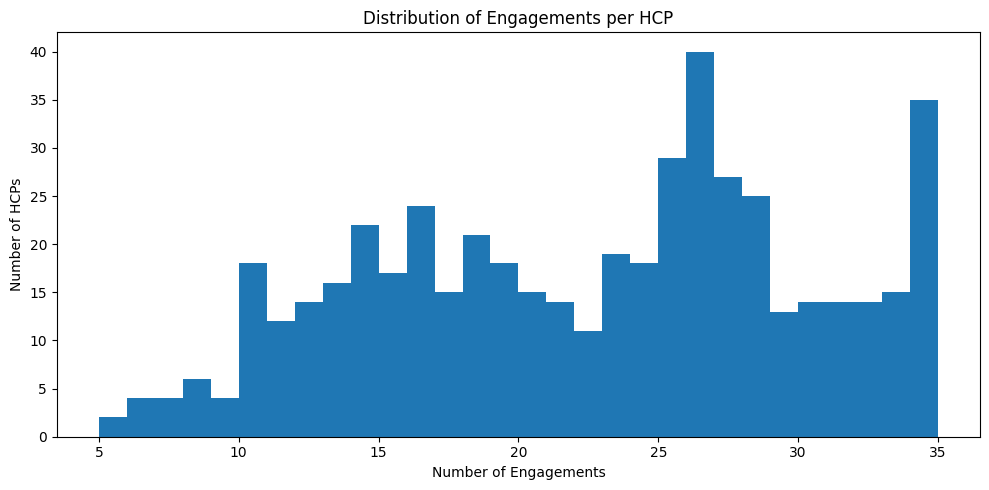

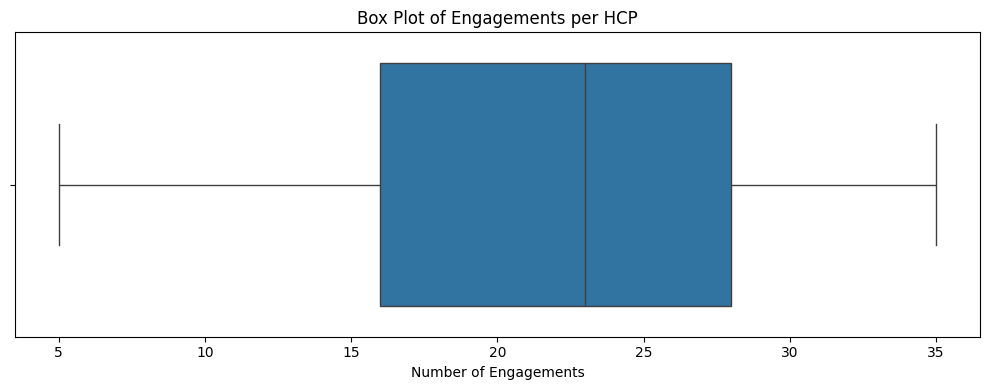


3.6 TOP 10 MOST ENGAGED HCPs
----------------------------------------


,hcp_id,engagement_count
386,387,35
466,467,35
186,187,35
483,484,35
388,389,35
397,398,35
361,362,35
360,361,35
362,363,35
55,56,35


In [ ]:
# ============================================================
# SECTION 3: ENGAGEMENT DISTRIBUTION ANALYSIS
# ============================================================

print("=" * 60)
print("SECTION 3: ENGAGEMENT DISTRIBUTION ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 3.1 Number of Unique HCPs
# ------------------------------------------------------------

print("\n3.1 UNIQUE HCPs")
print("-" * 40)

unique_hcps = df["hcp_id"].nunique()

print("Number of Unique HCPs:", unique_hcps)


# ------------------------------------------------------------
# 3.2 Engagement Count per HCP
# ------------------------------------------------------------

engagement_count = (
    df.groupby("hcp_id")
      .size()
      .reset_index(name="engagement_count")
)

print("\n3.2 ENGAGEMENT COUNT PER HCP")
print("-" * 40)

display(engagement_count.head())


# ------------------------------------------------------------
# 3.3 Statistical Summary
# ------------------------------------------------------------

print("\n3.3 ENGAGEMENT DISTRIBUTION SUMMARY")
print("-" * 40)

display(engagement_count["engagement_count"].describe())


# ------------------------------------------------------------
# 3.4 Histogram of Engagements per HCP
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    engagement_count["engagement_count"],
    bins=30
)

plt.title("Distribution of Engagements per HCP")
plt.xlabel("Number of Engagements")
plt.ylabel("Number of HCPs")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3.5 Box Plot for Engagement Count
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=engagement_count["engagement_count"]
)

plt.title("Box Plot of Engagements per HCP")
plt.xlabel("Number of Engagements")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3.6 Top 10 Most Engaged HCPs
# ------------------------------------------------------------

print("\n3.6 TOP 10 MOST ENGAGED HCPs")
print("-" * 40)

top_hcps = (
    engagement_count
    .sort_values("engagement_count", ascending=False)
    .head(10)
)

display(top_hcps)

SECTION 4: ENGAGEMENT CHANNEL ANALYSIS

4.1 CHANNEL DISTRIBUTION
----------------------------------------


,count
channel,
email,2601
phone_call,2493
rep_visit,2326
digital_ad,1948
webinar,1671



4.2 CHANNEL PERCENTAGE
----------------------------------------


,proportion
channel,
email,23.56
phone_call,22.58
rep_visit,21.07
digital_ad,17.65
webinar,15.14


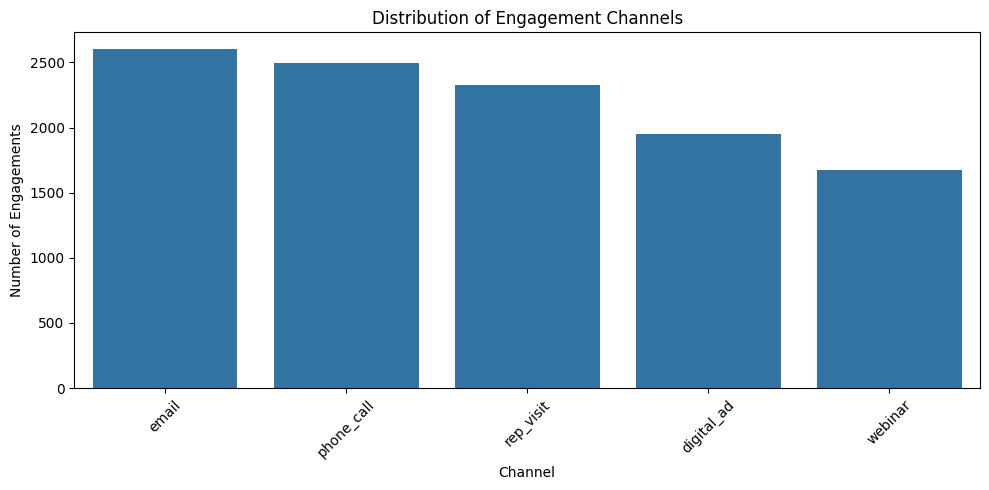


4.4 HCP × CHANNEL DISTRIBUTION
----------------------------------------


channel,digital_ad,email,phone_call,rep_visit,webinar
hcp_id,,,,,
1,1,10,4,3,5
2,2,3,3,1,2
3,15,7,3,2,3
4,3,6,7,2,8
5,1,2,8,12,3
6,0,1,5,5,3
7,2,2,9,16,4
8,6,11,5,1,4
9,9,7,6,4,3



Most Frequently Used Channel: email


In [ ]:
# ============================================================
# SECTION 4: ENGAGEMENT CHANNEL ANALYSIS
# ============================================================

print("=" * 60)
print("SECTION 4: ENGAGEMENT CHANNEL ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 4.1 Channel Distribution
# ------------------------------------------------------------

channel_count = df["channel"].value_counts()

print("\n4.1 CHANNEL DISTRIBUTION")
print("-" * 40)

display(channel_count)


# ------------------------------------------------------------
# 4.2 Channel Percentage
# ------------------------------------------------------------

channel_percentage = (
    df["channel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n4.2 CHANNEL PERCENTAGE")
print("-" * 40)

display(channel_percentage)


# ------------------------------------------------------------
# 4.3 Channel Distribution Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="channel",
    order=df["channel"].value_counts().index
)

plt.title("Distribution of Engagement Channels")
plt.xlabel("Channel")
plt.ylabel("Number of Engagements")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4.4 HCP × Channel Distribution
# ------------------------------------------------------------

hcp_channel = pd.crosstab(
    df["hcp_id"],
    df["channel"]
)

print("\n4.4 HCP × CHANNEL DISTRIBUTION")
print("-" * 40)

display(hcp_channel.head(10))


# ------------------------------------------------------------
# 4.5 Most Frequently Used Channel
# ------------------------------------------------------------

most_used_channel = df["channel"].value_counts().idxmax()

print("\nMost Frequently Used Channel:",
      most_used_channel)

SECTION 5: ENGAGEMENT SUCCESS ANALYSIS

5.1 SUCCESS DISTRIBUTION
----------------------------------------


,count
engagement_successful,
0,7798
1,3241



5.2 SUCCESS PERCENTAGE
----------------------------------------


,proportion
engagement_successful,
0,70.64
1,29.36



5.3 OVERALL SUCCESS RATE
----------------------------------------
Overall Engagement Success Rate: 29.36%


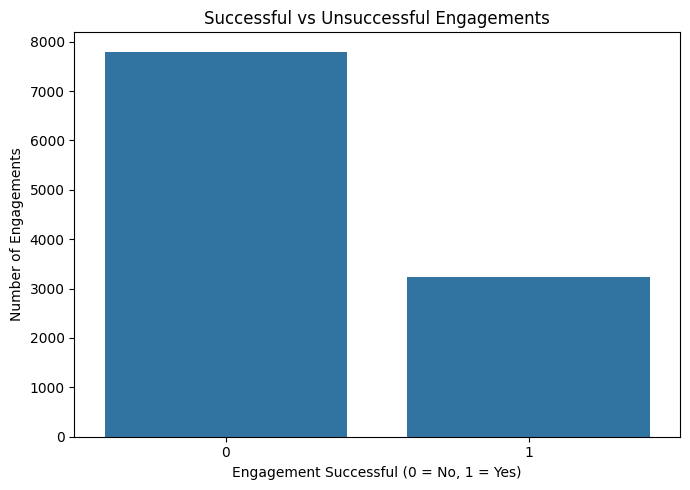


5.5 CHANNEL-WISE SUCCESS RATE
----------------------------------------


,total_engagements,successful_engagements,success_rate
channel,,,
digital_ad,1948,202,10.37
email,2601,518,19.92
phone_call,2493,728,29.20
rep_visit,2326,1301,55.93
webinar,1671,492,29.44


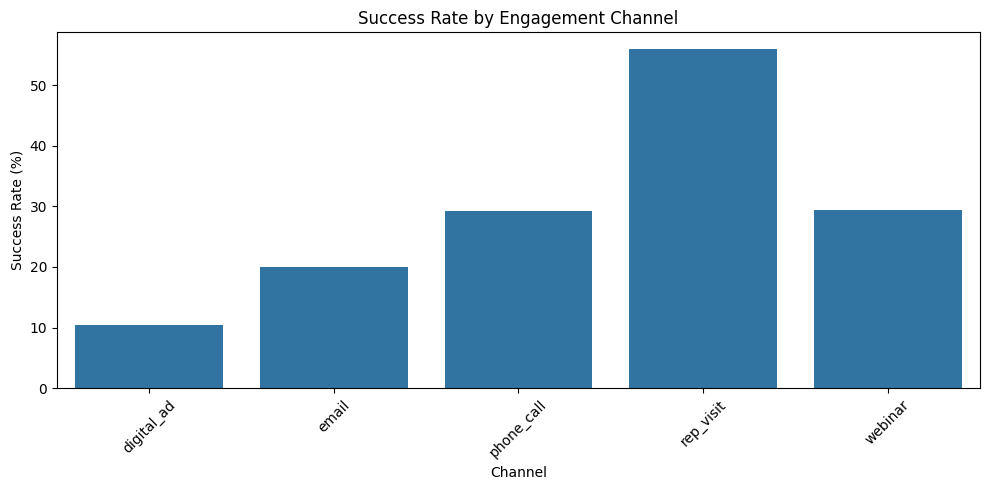


5.7 CHANNEL × SUCCESS
----------------------------------------


engagement_successful,0,1
channel,,
digital_ad,1746,202
email,2083,518
phone_call,1765,728
rep_visit,1025,1301
webinar,1179,492



5.8 HCP-WISE SUCCESS RATE
----------------------------------------


,total_engagements,successful_engagements,unsuccessful_engagements,success_rate
hcp_id,,,,
1,23,4,19,17.39
2,11,1,10,9.09
3,30,1,29,3.33
4,26,9,17,34.62
5,26,14,12,53.85
6,14,3,11,21.43
7,33,16,17,48.48
8,27,5,22,18.52
9,29,9,20,31.03



5.9 HCPs WITH HIGHEST SUCCESS RATE
----------------------------------------


,total_engagements,successful_engagements,unsuccessful_engagements,success_rate
hcp_id,,,,
100,7,6,1,85.71
292,12,10,2,83.33
378,10,8,2,80.00
286,15,11,4,73.33
410,10,7,3,70.00
20,10,7,3,70.00
185,10,7,3,70.00
355,25,17,8,68.00
348,9,6,3,66.67


In [ ]:
# ============================================================
# SECTION 5: ENGAGEMENT SUCCESS ANALYSIS
# ============================================================

print("=" * 60)
print("SECTION 5: ENGAGEMENT SUCCESS ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 5.1 Success Distribution
# ------------------------------------------------------------

success_count = df["engagement_successful"].value_counts()

print("\n5.1 SUCCESS DISTRIBUTION")
print("-" * 40)

display(success_count)


# ------------------------------------------------------------
# 5.2 Success Percentage
# ------------------------------------------------------------

success_percentage = (
    df["engagement_successful"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n5.2 SUCCESS PERCENTAGE")
print("-" * 40)

display(success_percentage)


# ------------------------------------------------------------
# 5.3 Overall Success Rate
# ------------------------------------------------------------

overall_success_rate = (
    df["engagement_successful"].mean() * 100
)

print("\n5.3 OVERALL SUCCESS RATE")
print("-" * 40)

print(f"Overall Engagement Success Rate: "
      f"{overall_success_rate:.2f}%")


# ------------------------------------------------------------
# 5.4 Success Distribution Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="engagement_successful"
)

plt.title("Successful vs Unsuccessful Engagements")
plt.xlabel("Engagement Successful (0 = No, 1 = Yes)")
plt.ylabel("Number of Engagements")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.5 Channel-wise Success Rate
# ------------------------------------------------------------

channel_success = (
    df.groupby("channel")["engagement_successful"]
      .agg(
          total_engagements="count",
          successful_engagements="sum",
          success_rate="mean"
      )
)

channel_success["success_rate"] *= 100

channel_success["success_rate"] = (
    channel_success["success_rate"].round(2)
)

print("\n5.5 CHANNEL-WISE SUCCESS RATE")
print("-" * 40)

display(channel_success)


# ------------------------------------------------------------
# 5.6 Channel-wise Success Rate Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.barplot(
    data=channel_success.reset_index(),
    x="channel",
    y="success_rate"
)

plt.title("Success Rate by Engagement Channel")
plt.xlabel("Channel")
plt.ylabel("Success Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.7 Channel × Success Crosstab
# ------------------------------------------------------------

channel_success_crosstab = pd.crosstab(
    df["channel"],
    df["engagement_successful"]
)

print("\n5.7 CHANNEL × SUCCESS")
print("-" * 40)

display(channel_success_crosstab)


# ------------------------------------------------------------
# 5.8 HCP-wise Success Rate
# ------------------------------------------------------------

hcp_success = (
    df.groupby("hcp_id")["engagement_successful"]
      .agg(
          total_engagements="count",
          successful_engagements="sum",
          unsuccessful_engagements=lambda x: (x == 0).sum(),
          success_rate="mean"
      )
)

hcp_success["success_rate"] *= 100

hcp_success["success_rate"] = (
    hcp_success["success_rate"].round(2)
)

print("\n5.8 HCP-WISE SUCCESS RATE")
print("-" * 40)

display(hcp_success.head(10))


# ------------------------------------------------------------
# 5.9 Highest Success Rate HCPs
# ------------------------------------------------------------

print("\n5.9 HCPs WITH HIGHEST SUCCESS RATE")
print("-" * 40)

display(
    hcp_success
    .sort_values("success_rate", ascending=False)
    .head(10)
)

SECTION 6: TEMPORAL ANALYSIS

6.1 ENGAGEMENT DATE RANGE
----------------------------------------
First Engagement : 2025-01-14 08:00:00
Last Engagement  : 2026-01-02 17:00:00
Duration: 353 days 09:00:00

6.3 MONTHLY ENGAGEMENT COUNT
----------------------------------------


,0
engagement_date,
2025-01-31,622
2025-02-28,928
2025-03-31,903
2025-04-30,972
2025-05-31,978
2025-06-30,925
2025-07-31,996
2025-08-31,898
2025-09-30,961


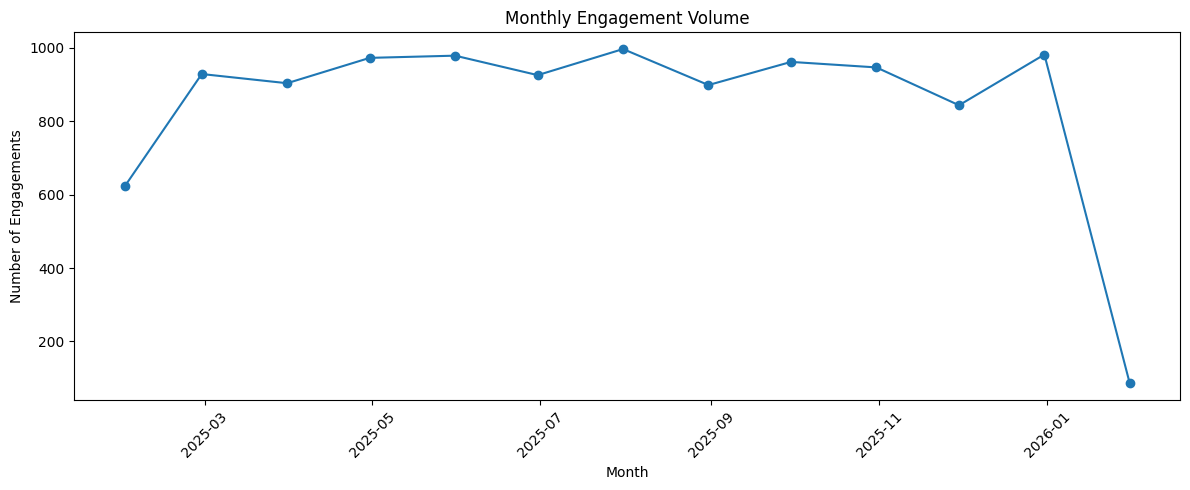


6.5 MONTHLY SUCCESSFUL ENGAGEMENTS
----------------------------------------


,engagement_successful
engagement_date,
2025-01-31,234
2025-02-28,268
2025-03-31,281
2025-04-30,300
2025-05-31,288
2025-06-30,261
2025-07-31,263
2025-08-31,255
2025-09-30,265



6.6 MONTHLY SUCCESS RATE
----------------------------------------


,engagement_successful
engagement_date,
2025-01-31,37.62
2025-02-28,28.88
2025-03-31,31.12
2025-04-30,30.86
2025-05-31,29.45
2025-06-30,28.22
2025-07-31,26.41
2025-08-31,28.40
2025-09-30,27.58


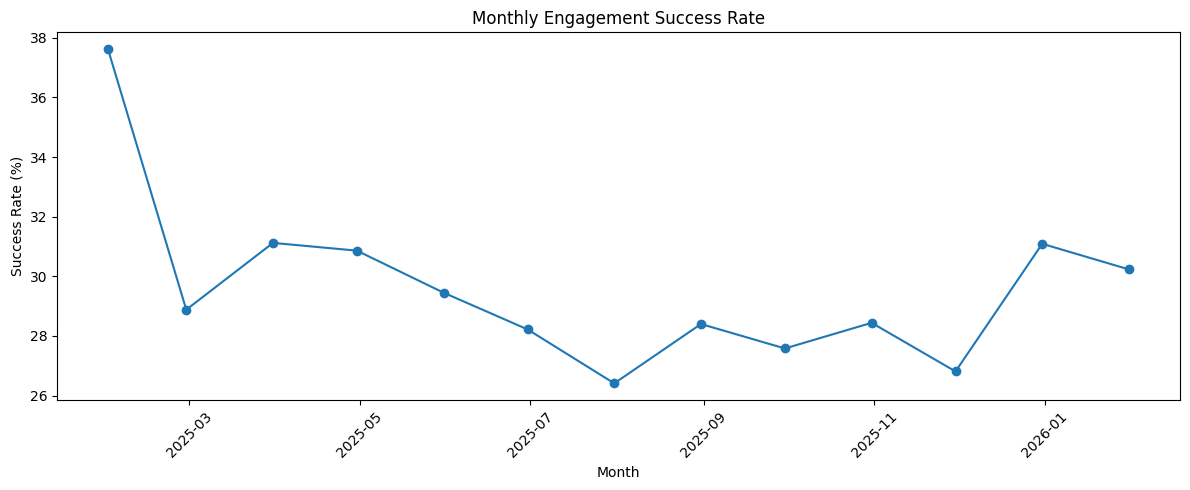


6.8 CHANNEL USAGE OVER TIME
----------------------------------------


channel,digital_ad,email,phone_call,rep_visit,webinar
engagement_date,,,,,
2025-01,103,171,132,120,96
2025-02,164,219,211,185,149
2025-03,154,227,180,202,140
2025-04,160,212,225,212,163
2025-05,172,237,223,206,140
2025-06,160,221,227,187,130
2025-07,175,242,227,211,141
2025-08,174,190,225,169,140
2025-09,154,221,221,214,151


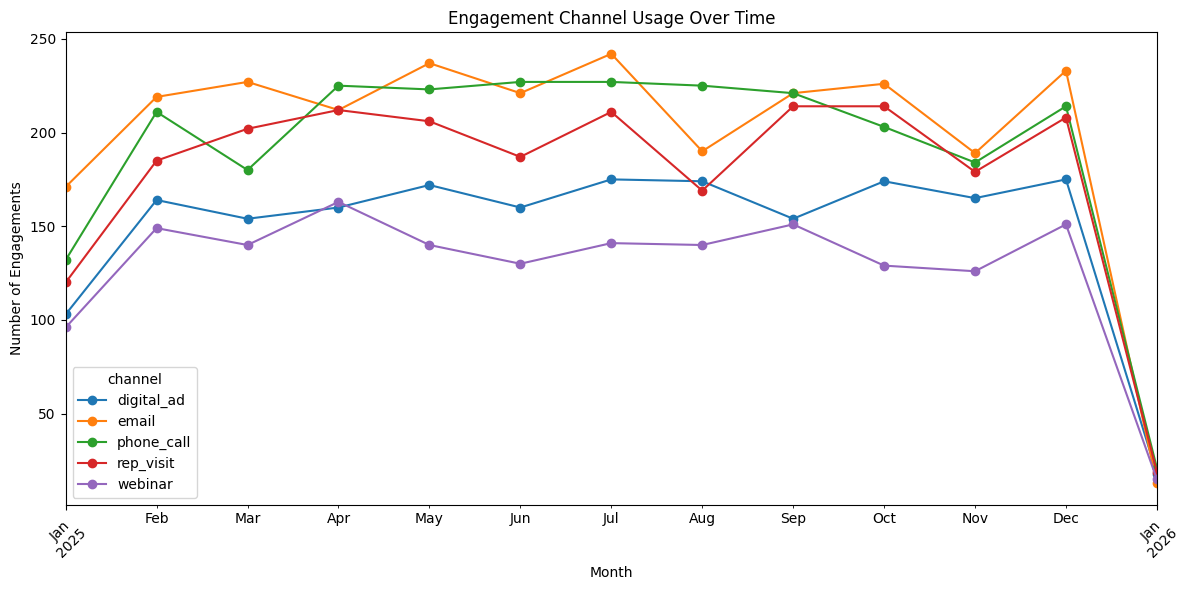


6.10 DAY-OF-WEEK ENGAGEMENT
----------------------------------------


,count
day_of_week,
Monday,1882.0
Tuesday,2217.0
Wednesday,2181.0
Thursday,2225.0
Friday,2255.0
Saturday,279.0
Sunday,NaN


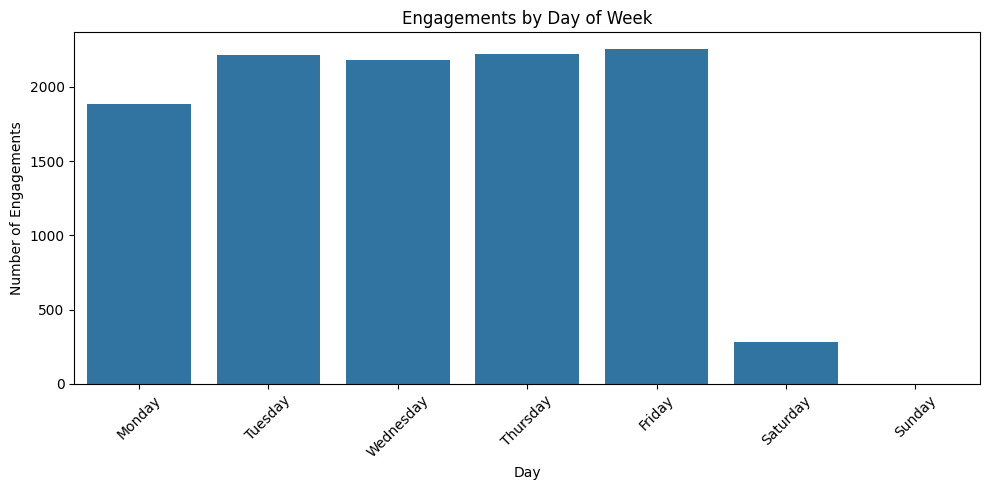


6.12 DAY-OF-WEEK SUCCESS RATE
----------------------------------------


,engagement_successful
day_of_week,
Monday,23.86
Tuesday,28.64
Wednesday,28.34
Thursday,31.28
Friday,33.35
Saturday,32.62
Sunday,NaN



6.13 HOURLY ENGAGEMENT DISTRIBUTION
----------------------------------------


,count
hour,
8,1077
9,1127
10,1100
11,1158
12,1116
13,1042
14,1119
15,1042
16,1078


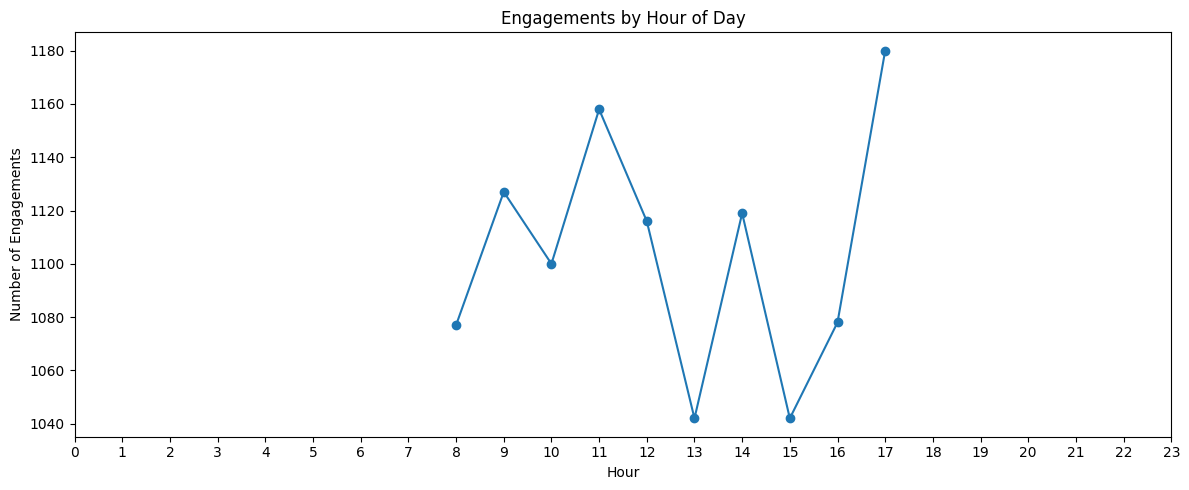

In [ ]:
# ============================================================
# SECTION 6: TEMPORAL ANALYSIS
# ============================================================

print("=" * 60)
print("SECTION 6: TEMPORAL ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 6.1 Engagement Date Range
# ------------------------------------------------------------

print("\n6.1 ENGAGEMENT DATE RANGE")
print("-" * 40)

minimum_date = df["engagement_date"].min()
maximum_date = df["engagement_date"].max()

print("First Engagement :", minimum_date)
print("Last Engagement  :", maximum_date)

print(
    "Duration:",
    maximum_date - minimum_date
)


# ------------------------------------------------------------
# 6.2 Extract Temporal Components
# ------------------------------------------------------------

df["year"] = df["engagement_date"].dt.year
df["month"] = df["engagement_date"].dt.month
df["month_name"] = df["engagement_date"].dt.month_name()
df["day_of_week"] = df["engagement_date"].dt.day_name()
df["hour"] = df["engagement_date"].dt.hour


# ------------------------------------------------------------
# 6.3 Monthly Engagement Count
# ------------------------------------------------------------

monthly_engagement = (
    df.set_index("engagement_date")
      .resample("ME")
      .size()
)

print("\n6.3 MONTHLY ENGAGEMENT COUNT")
print("-" * 40)

display(monthly_engagement)


# ------------------------------------------------------------
# 6.4 Monthly Engagement Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_engagement.index,
    monthly_engagement.values,
    marker="o"
)

plt.title("Monthly Engagement Volume")
plt.xlabel("Month")
plt.ylabel("Number of Engagements")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6.5 Monthly Successful Engagements
# ------------------------------------------------------------

monthly_success = (
    df.set_index("engagement_date")
      .resample("ME")["engagement_successful"]
      .sum()
)

print("\n6.5 MONTHLY SUCCESSFUL ENGAGEMENTS")
print("-" * 40)

display(monthly_success)


# ------------------------------------------------------------
# 6.6 Monthly Success Rate
# ------------------------------------------------------------

monthly_success_rate = (
    df.set_index("engagement_date")
      .resample("ME")["engagement_successful"]
      .mean()
      .mul(100)
      .round(2)
)

print("\n6.6 MONTHLY SUCCESS RATE")
print("-" * 40)

display(monthly_success_rate)


# ------------------------------------------------------------
# 6.7 Monthly Success Rate Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_success_rate.index,
    monthly_success_rate.values,
    marker="o"
)

plt.title("Monthly Engagement Success Rate")
plt.xlabel("Month")
plt.ylabel("Success Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6.8 Channel Usage Over Time
# ------------------------------------------------------------

monthly_channel = pd.crosstab(
    df["engagement_date"].dt.to_period("M"),
    df["channel"]
)

print("\n6.8 CHANNEL USAGE OVER TIME")
print("-" * 40)

display(monthly_channel)


# ------------------------------------------------------------
# 6.9 Channel Usage Over Time Plot
# ------------------------------------------------------------

monthly_channel.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("Engagement Channel Usage Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Engagements")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6.10 Day-of-Week Analysis
# ------------------------------------------------------------

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_engagement = (
    df["day_of_week"]
    .value_counts()
    .reindex(weekday_order)
)

print("\n6.10 DAY-OF-WEEK ENGAGEMENT")
print("-" * 40)

display(weekday_engagement)


# ------------------------------------------------------------
# 6.11 Day-of-Week Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_engagement.index,
    y=weekday_engagement.values
)

plt.title("Engagements by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Engagements")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6.12 Day-of-Week Success Rate
# ------------------------------------------------------------

weekday_success = (
    df.groupby("day_of_week")["engagement_successful"]
      .mean()
      .reindex(weekday_order)
      .mul(100)
      .round(2)
)

print("\n6.12 DAY-OF-WEEK SUCCESS RATE")
print("-" * 40)

display(weekday_success)


# ------------------------------------------------------------
# 6.13 Time-of-Day Analysis
# ------------------------------------------------------------

hourly_engagement = (
    df["hour"]
    .value_counts()
    .sort_index()
)

print("\n6.13 HOURLY ENGAGEMENT DISTRIBUTION")
print("-" * 40)

display(hourly_engagement)


# ------------------------------------------------------------
# 6.14 Hourly Engagement Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_engagement.index,
    hourly_engagement.values,
    marker="o"
)

plt.title("Engagements by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Engagements")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

SECTION 7: ENGAGEMENT BEHAVIOR ANALYSIS

7.1 LAST ENGAGEMENT DATE PER HCP
----------------------------------------


,hcp_id,last_engagement_date
0,1,2025-12-26 10:00:00
1,2,2025-09-29 10:00:00
2,3,2025-12-25 08:00:00
3,4,2026-01-01 15:00:00
4,5,2026-01-02 17:00:00
5,6,2025-11-26 09:00:00
6,7,2025-12-04 14:00:00
7,8,2025-12-15 14:00:00
8,9,2026-01-01 13:00:00
9,10,2025-12-30 12:00:00



7.2 ENGAGEMENT RECENCY
----------------------------------------


,hcp_id,last_engagement_date,recency_days
0,1,2025-12-26 10:00:00,7
1,2,2025-09-29 10:00:00,95
2,3,2025-12-25 08:00:00,8
3,4,2026-01-01 15:00:00,1
4,5,2026-01-02 17:00:00,0
5,6,2025-11-26 09:00:00,37
6,7,2025-12-04 14:00:00,29
7,8,2025-12-15 14:00:00,18
8,9,2026-01-01 13:00:00,1
9,10,2025-12-30 12:00:00,3



7.3 RECENCY STATISTICS
----------------------------------------


,recency_days
count,500.000000
mean,13.706000
std,17.221287
min,0.000000
25%,2.000000
50%,8.000000
75%,18.000000
max,123.000000


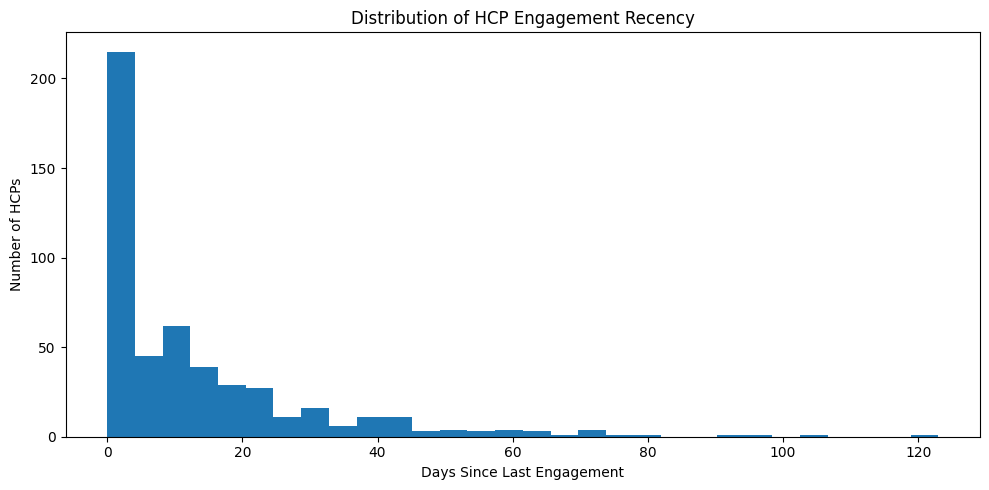


7.5 ENGAGEMENT INTERVALS
----------------------------------------


,hcp_id,engagement_date,previous_engagement_date,engagement_interval_days
0,1,2025-01-16 17:00:00,NaT,NaN
1,1,2025-02-21 16:00:00,2025-01-16 17:00:00,35.958333
2,1,2025-02-25 16:00:00,2025-02-21 16:00:00,4.000000
3,1,2025-03-13 14:00:00,2025-02-25 16:00:00,15.916667
4,1,2025-03-25 11:00:00,2025-03-13 14:00:00,11.875000
5,1,2025-04-28 14:00:00,2025-03-25 11:00:00,34.125000
6,1,2025-05-14 17:00:00,2025-04-28 14:00:00,16.125000
7,1,2025-06-18 16:00:00,2025-05-14 17:00:00,34.958333
8,1,2025-06-26 09:00:00,2025-06-18 16:00:00,7.708333
9,1,2025-07-17 10:00:00,2025-06-26 09:00:00,21.041667



7.6 ENGAGEMENT INTERVAL STATISTICS
----------------------------------------


,engagement_interval_days
count,10539.000000
mean,15.498632
std,13.717943
min,2.625000
25%,7.041667
50%,11.000000
75%,19.000000
max,233.333333



7.7 AVERAGE ENGAGEMENT INTERVAL PER HCP
----------------------------------------


,hcp_id,average_engagement_interval_days
0,1,15.623106
1,2,24.108333
2,3,11.853448
3,4,14.005000
4,5,13.480000
5,6,20.512821
6,7,10.130208
7,8,12.346154
8,9,12.575893
9,10,30.814394



7.8 ENGAGEMENT SEQUENCE EXAMPLE
----------------------------------------


,hcp_id,engagement_date,channel,engagement_successful
0,1,2025-01-16 17:00:00,email,1
1,1,2025-02-21 16:00:00,email,1
2,1,2025-02-25 16:00:00,email,0
3,1,2025-03-13 14:00:00,email,0
4,1,2025-03-25 11:00:00,email,0
5,1,2025-04-28 14:00:00,rep_visit,0
6,1,2025-05-14 17:00:00,webinar,0
7,1,2025-06-18 16:00:00,email,0
8,1,2025-06-26 09:00:00,phone_call,0
9,1,2025-07-17 10:00:00,phone_call,0


In [ ]:
# ============================================================
# SECTION 7: ENGAGEMENT BEHAVIOR ANALYSIS
# ============================================================

print("=" * 60)
print("SECTION 7: ENGAGEMENT BEHAVIOR ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 7.1 Most Recent Engagement of Each HCP
# ------------------------------------------------------------

hcp_last_engagement = (
    df.groupby("hcp_id")["engagement_date"]
      .max()
      .reset_index()
)

hcp_last_engagement.columns = [
    "hcp_id",
    "last_engagement_date"
]

print("\n7.1 LAST ENGAGEMENT DATE PER HCP")
print("-" * 40)

display(hcp_last_engagement.head(10))


# ------------------------------------------------------------
# 7.2 Engagement Recency
# ------------------------------------------------------------

reference_date = df["engagement_date"].max()

hcp_last_engagement["recency_days"] = (
    reference_date -
    hcp_last_engagement["last_engagement_date"]
).dt.days

print("\n7.2 ENGAGEMENT RECENCY")
print("-" * 40)

display(
    hcp_last_engagement.head(10)
)


# ------------------------------------------------------------
# 7.3 Recency Statistics
# ------------------------------------------------------------

print("\n7.3 RECENCY STATISTICS")
print("-" * 40)

display(
    hcp_last_engagement["recency_days"].describe()
)


# ------------------------------------------------------------
# 7.4 Recency Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    hcp_last_engagement["recency_days"],
    bins=30
)

plt.title("Distribution of HCP Engagement Recency")
plt.xlabel("Days Since Last Engagement")
plt.ylabel("Number of HCPs")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7.5 Engagement Intervals
# ------------------------------------------------------------

df_sorted = df.sort_values(
    ["hcp_id", "engagement_date"]
).copy()

df_sorted["previous_engagement_date"] = (
    df_sorted
    .groupby("hcp_id")["engagement_date"]
    .shift(1)
)

df_sorted["engagement_interval_days"] = (
    df_sorted["engagement_date"] -
    df_sorted["previous_engagement_date"]
).dt.total_seconds() / (24 * 60 * 60)


print("\n7.5 ENGAGEMENT INTERVALS")
print("-" * 40)

display(
    df_sorted[
        [
            "hcp_id",
            "engagement_date",
            "previous_engagement_date",
            "engagement_interval_days"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 7.6 Engagement Interval Statistics
# ------------------------------------------------------------

print("\n7.6 ENGAGEMENT INTERVAL STATISTICS")
print("-" * 40)

display(
    df_sorted["engagement_interval_days"].describe()
)


# ------------------------------------------------------------
# 7.7 Average Engagement Interval per HCP
# ------------------------------------------------------------

hcp_interval = (
    df_sorted
    .groupby("hcp_id")["engagement_interval_days"]
    .mean()
    .reset_index()
)

hcp_interval.columns = [
    "hcp_id",
    "average_engagement_interval_days"
]

print("\n7.7 AVERAGE ENGAGEMENT INTERVAL PER HCP")
print("-" * 40)

display(hcp_interval.head(10))


# ------------------------------------------------------------
# 7.8 Engagement Sequence Example
# ------------------------------------------------------------

print("\n7.8 ENGAGEMENT SEQUENCE EXAMPLE")
print("-" * 40)

example_hcp = df_sorted["hcp_id"].iloc[0]

example_sequence = (
    df_sorted[df_sorted["hcp_id"] == example_hcp]
    [["hcp_id", "engagement_date", "channel",
      "engagement_successful"]]
)

display(example_sequence)

In [ ]:
# ============================================================
# SECTION 8: FINAL EDA SUMMARY
# ============================================================

print("=" * 60)
print("SECTION 8: FINAL EDA SUMMARY")
print("=" * 60)


# ------------------------------------------------------------
# 8.1 Basic Dataset Statistics
# ------------------------------------------------------------

total_records = len(df)

unique_hcps = df["hcp_id"].nunique()

unique_channels = df["channel"].nunique()

successful_engagements = (
    df["engagement_successful"].sum()
)

unsuccessful_engagements = (
    (df["engagement_successful"] == 0).sum()
)

overall_success_rate = (
    df["engagement_successful"].mean() * 100
)

average_engagements_per_hcp = (
    df.groupby("hcp_id").size().mean()
)

median_engagements_per_hcp = (
    df.groupby("hcp_id").size().median()
)

most_used_channel = (
    df["channel"].value_counts().idxmax()
)

best_performing_channel = (
    channel_success["success_rate"].idxmax()
)


# ------------------------------------------------------------
# 8.2 Summary Table
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Total Engagement Records",
        "Unique HCPs",
        "Number of Channels",
        "Successful Engagements",
        "Unsuccessful Engagements",
        "Overall Success Rate (%)",
        "Average Engagements per HCP",
        "Median Engagements per HCP",
        "Most Used Channel",
        "Best Performing Channel"
    ],

    "Value": [
        total_records,
        unique_hcps,
        unique_channels,
        successful_engagements,
        unsuccessful_engagements,
        round(overall_success_rate, 2),
        round(average_engagements_per_hcp, 2),
        median_engagements_per_hcp,
        most_used_channel,
        best_performing_channel
    ]
})

display(summary)


# ------------------------------------------------------------
# 8.3 Date Range Summary
# ------------------------------------------------------------

print("\nDATE RANGE")
print("-" * 40)

print("First Engagement :", minimum_date)
print("Last Engagement  :", maximum_date)


# ------------------------------------------------------------
# 8.4 Key Findings
# ------------------------------------------------------------

print("\nKEY FINDINGS")
print("-" * 40)

print(
    f"1. The dataset contains {total_records:,} engagement records."
)

print(
    f"2. The records belong to {unique_hcps:,} unique HCPs."
)

print(
    f"3. There are {unique_channels} different engagement channels."
)

print(
    f"4. The overall engagement success rate is "
    f"{overall_success_rate:.2f}%."
)

print(
    f"5. The most frequently used channel is "
    f"'{most_used_channel}'."
)

print(
    f"6. The channel with the highest success rate is "
    f"'{best_performing_channel}'."
)

print(
    f"7. The average number of engagements per HCP is "
    f"{average_engagements_per_hcp:.2f}."
)

SECTION 8: FINAL EDA SUMMARY


,Metric,Value
0,Total Engagement Records,11039
1,Unique HCPs,500
2,Number of Channels,5
3,Successful Engagements,3241
4,Unsuccessful Engagements,7798
5,Overall Success Rate (%),29.36
6,Average Engagements per HCP,22.08
7,Median Engagements per HCP,23.0
8,Most Used Channel,email
9,Best Performing Channel,rep_visit



DATE RANGE
----------------------------------------
First Engagement : 2025-01-14 08:00:00
Last Engagement  : 2026-01-02 17:00:00

KEY FINDINGS
----------------------------------------
1. The dataset contains 11,039 engagement records.
2. The records belong to 500 unique HCPs.
3. There are 5 different engagement channels.
4. The overall engagement success rate is 29.36%.
5. The most frequently used channel is 'email'.
6. The channel with the highest success rate is 'rep_visit'.
7. The average number of engagements per HCP is 22.08.


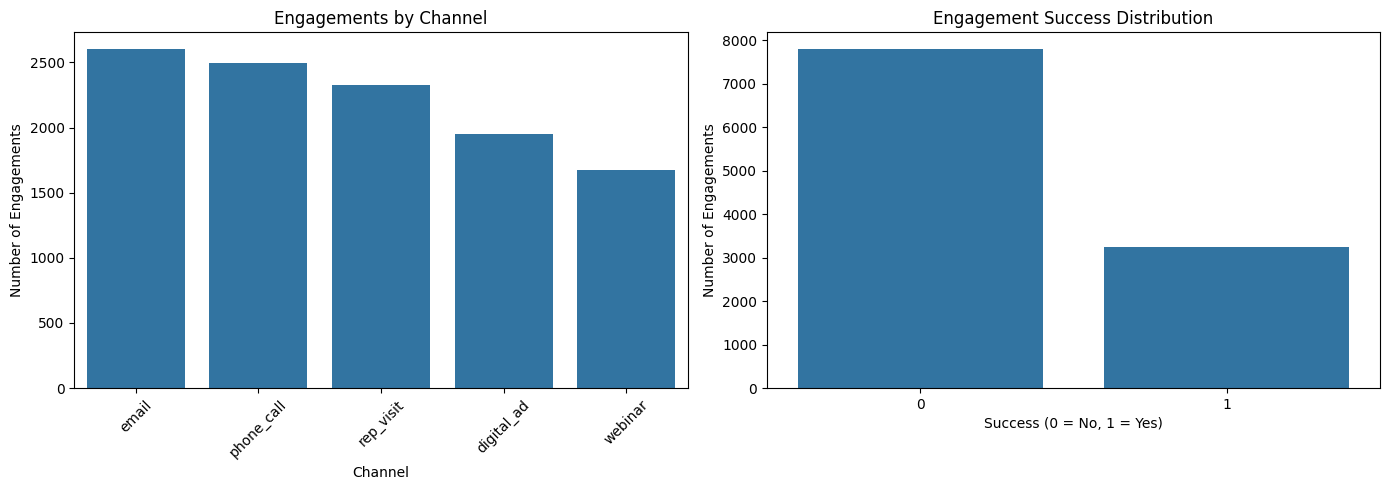

In [ ]:
# ============================================================
# OVERALL ENGAGEMENT SUMMARY VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Channel distribution
sns.countplot(
    data=df,
    x="channel",
    order=df["channel"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Engagements by Channel")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Number of Engagements")
axes[0].tick_params(axis="x", rotation=45)


# Success distribution
sns.countplot(
    data=df,
    x="engagement_successful",
    ax=axes[1]
)

axes[1].set_title("Engagement Success Distribution")
axes[1].set_xlabel("Success (0 = No, 1 = Yes)")
axes[1].set_ylabel("Number of Engagements")

plt.tight_layout()
plt.show()